### Dataset

In [1]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from transformers import TrOCRProcessor
from torch.utils.data import random_split, DataLoader
import torch

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")

class RxHandBDDataset(Dataset):
    def __init__(self, csv_path, image_dir, processor):
        self.df = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]  # Get the row at index idx

        image_path = os.path.join(self.image_dir, row["Images"])
        image = Image.open(image_path).convert("RGB")

        text = row["Text"]

        # Converting our image pixels to tensor
        pixel_values = self.processor(
            images=image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        # Convert our ground truth to token ids
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=64,
            truncation=True,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        # Dataloader automatically batches these so its fine
        return {
            "pixel_values": pixel_values,
            "labels": labels,
        }

In [2]:
dataset = RxHandBDDataset(
    "/workspace/rxhandbd/RxHandBD-ML/Train_Label.csv",
    "/workspace/rxhandbd/RxHandBD-ML/Train_Set",
    processor
)

val_fraction = 0.08

num_total = len(dataset)
num_val = int(num_total * val_fraction)
num_train = num_total - num_val

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    dataset,
    [num_train, num_val],
    generator=generator
)

print("train:", len(train_dataset))
print("val:", len(val_dataset))


train: 4106
val: 357


### DataLoader

In [3]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

def data_collator(features):
    pixel_values = torch.stack([f["pixel_values"] for f in features])
    labels = torch.stack([f["labels"] for f in features])

    return {
        "pixel_values": pixel_values,
        "labels": labels,
    }

### Align the Model to the Processor. 
Make sure that start, pad, and eos are the same

In [4]:
def align_model_to_processor(model, processor):
    tokenizer = processor.tokenizer

    model.config.decoder_start_token_id = tokenizer.cls_token_id
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.sep_token_id

    model.generation_config.decoder_start_token_id = tokenizer.cls_token_id
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.sep_token_id

    # Useful for generation later
    model.generation_config.max_length = 64
    model.generation_config.num_beams = 1

    return model

### Define the VisionEncoderDecoder Model

In [5]:
import torch
from transformers import VisionEncoderDecoderModel

device = torch.device("cuda")

model = VisionEncoderDecoderModel.from_pretrained(
    "microsoft/trocr-base-handwritten"
).to(device)

model = align_model_to_processor(model, processor)



Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Sanity check special token alignment

In [6]:
def check_trocr_alignment(model, processor):
    tokenizer = processor.tokenizer

    expected_decoder_start = tokenizer.cls_token_id
    expected_pad = tokenizer.pad_token_id
    expected_eos = tokenizer.sep_token_id

    checks = {
        "model.config.decoder_start_token_id": (
            model.config.decoder_start_token_id,
            expected_decoder_start,
        ),
        "model.config.pad_token_id": (
            model.config.pad_token_id,
            expected_pad,
        ),
        "model.config.eos_token_id": (
            model.config.eos_token_id,
            expected_eos,
        ),
        "model.generation_config.decoder_start_token_id": (
            model.generation_config.decoder_start_token_id,
            expected_decoder_start,
        ),
        "model.generation_config.pad_token_id": (
            model.generation_config.pad_token_id,
            expected_pad,
        ),
        "model.generation_config.eos_token_id": (
            model.generation_config.eos_token_id,
            expected_eos,
        ),
    }

    for name, (actual, expected) in checks.items():
        assert actual == expected, f"{name}: expected {expected}, got {actual}"

    print("TrOCR alignment check passed.")
    print(f"decoder_start_token_id = {expected_decoder_start}")
    print(f"pad_token_id           = {expected_pad}")
    print(f"eos_token_id           = {expected_eos}")

check_trocr_alignment(model, processor)

TrOCR alignment check passed.
decoder_start_token_id = 0
pad_token_id           = 1
eos_token_id           = 2


### WER, CER, Sequence Accuracy metrics

In [7]:
import numpy as np
import evaluate

cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(eval_pred):
    preds, labels = eval_pred

    # Sometimes preds can be a tuple; take the actual generated IDs.
    if isinstance(preds, tuple):
        preds = preds[0]

    pred_texts = processor.batch_decode(
        preds,
        skip_special_tokens=True
    )

    # Replace -100 so tokenizer can decode labels.
    labels = np.where(
        labels == -100,
        processor.tokenizer.pad_token_id,
        labels
    )

    true_texts = processor.batch_decode(
        labels,
        skip_special_tokens=True
    )

    cer = cer_metric.compute(
        predictions=pred_texts,
        references=true_texts
    )

    wer = wer_metric.compute(
        predictions=pred_texts,
        references=true_texts
    )

    seq_acc = np.mean([
        pred == true
        for pred, true in zip(pred_texts, true_texts)
    ])

    return {
        "cer": cer,
        "wer": wer,
        "seq_acc": seq_acc,
    }

In [8]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

OUTPUT_DIR = "outputs/trocr-rxhandbd-trainer"

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=5e-5,
    num_train_epochs=3,
    logging_steps=25,
    logging_strategy="steps",
    predict_with_generate=True,
    generation_max_length=64,
    generation_num_beams=1,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    save_total_limit=2,
    remove_unused_columns=False,
    report_to="none",
    seed=42,
    data_seed=42,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor,
)

train_out = trainer.train()

trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

val_metrics = trainer.evaluate()
print("Validation:", val_metrics)

test_dataset = RxHandBDDataset(
    csv_path="/workspace/rxhandbd/RxHandBD-ML/Test_Label.csv",
    image_dir="/workspace/rxhandbd/RxHandBD-ML/Test_Set",
    processor=processor
)

test_metrics = trainer.evaluate(
    eval_dataset=test_dataset,
    metric_key_prefix="test"
)

print("Test:", test_metrics)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 0}.


Epoch,Training Loss,Validation Loss,Cer,Wer,Seq Acc
1,0.741257,1.001062,0.298567,0.790754,0.392157
2,0.498346,0.674959,0.178344,0.506083,0.509804
3,0.167012,0.634032,0.111067,0.394161,0.605042


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Cer,Wer,Seq Acc
0.167012,0.634032,3,0.111067,0.394161,0.605042


Validation: {'eval_loss': 0.6340324282646179, 'eval_cer': 0.11106687898089172, 'eval_wer': 0.39416058394160586, 'eval_seq_acc': 0.6050420168067226}


Training Loss,Validation Loss,Epoch,Cer,Wer,Seq Acc
0.167012,1.999186,3,0.310990,0.693614,0.329148


Test: {'test_loss': 1.9991859197616577, 'test_cer': 0.31098976109215015, 'test_wer': 0.6936135812449474, 'test_seq_acc': 0.3291479820627803}


### Training Graphs

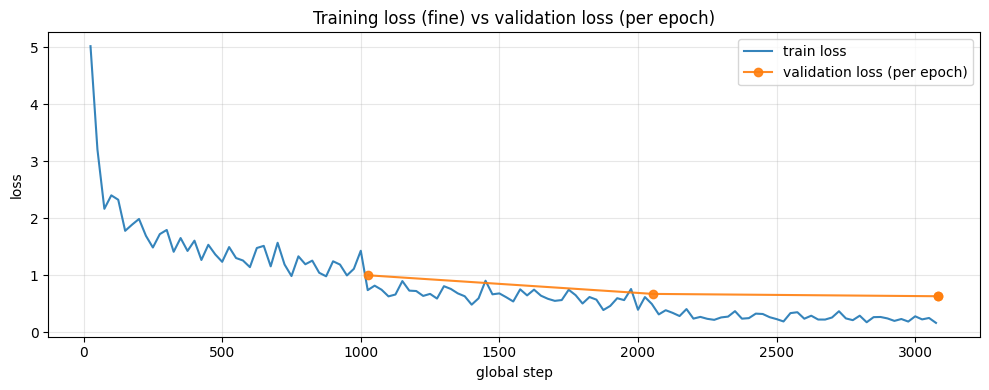

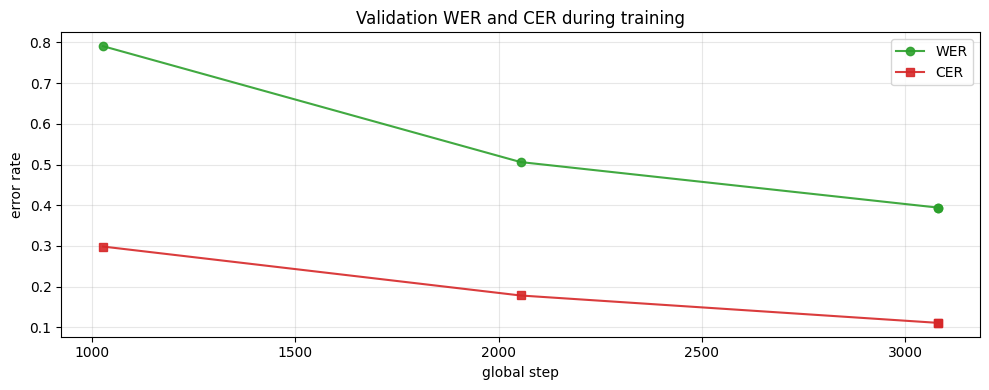

In [9]:
import matplotlib.pyplot as plt


def series(history, key):
    return [(int(r["step"]), float(r[key])) for r in history if key in r]


history = trainer.state.log_history
train_loss = series(history, "loss")
eval_loss = series(history, "eval_loss")
eval_wer = series(history, "eval_wer")
eval_cer = series(history, "eval_cer")

# Figure 1: fine-grained train loss + coarse per-epoch validation loss vs global step
fig1, ax1 = plt.subplots(figsize=(10, 4))
if train_loss:
    xs, ys = zip(*train_loss)
    ax1.plot(xs, ys, label="train loss", color="C0", alpha=0.9)
if eval_loss:
    xs, ys = zip(*eval_loss)
    ax1.plot(
        xs,
        ys,
        label="validation loss (per epoch)",
        color="C1",
        marker="o",
        linestyle="-",
        alpha=0.9,
    )
ax1.set_xlabel("global step")
ax1.set_ylabel("loss")
ax1.set_title("Training loss (fine) vs validation loss (per epoch)")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: eval WER and CER vs global step (per epoch)
fig2, ax2 = plt.subplots(figsize=(10, 4))
if eval_wer:
    xs, ys = zip(*eval_wer)
    ax2.plot(xs, ys, label="WER", color="C2", marker="o", linestyle="-", alpha=0.9)
if eval_cer:
    xs, ys = zip(*eval_cer)
    ax2.plot(xs, ys, label="CER", color="C3", marker="s", linestyle="-", alpha=0.9)
ax2.set_xlabel("global step")
ax2.set_ylabel("error rate")
ax2.set_title("Validation WER and CER during training")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()